# Robust Sleep Staging with a CNN

This notebook mirrors the structure of `RobustSleepStagingV2`, but replaces the Random Forest pipeline with a convolutional neural network based on `SleepStagerChambon2018`.

The workflow is: load Sleep-EDF recordings, preprocess them into 30-second epochs, train a CNN on Sleep Cassette, and evaluate both in-distribution (`SC → SC`) and under distribution shift (`SC → ST`).

---

## 1. Imports & configuration

This notebook keeps the same overall evaluation style as the RF notebook, but feeds raw epoched signals directly into the CNN instead of computing PSD features.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight
from skorch.callbacks import EarlyStopping, EpochScoring, Checkpoint
from skorch.helper import predefined_split
from skorch.dataset import Dataset

from braindecode import EEGClassifier
from braindecode.models import SleepStagerChambon2018
from braindecode.util import set_random_seeds

from rss import evaluate, preprocess

# Use only EEG channels for the CNN to reduce memory and speed up training
CHANNELS = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

print('✓ Core libraries imported')

✓ Core libraries imported


In [2]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
CNN_FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/CNN_ALL_CH/sc'
CNN_FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/CNN_ALL_CH/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/CNN_ALL_CH'

for path in [CNN_FEATURE_DIR_SC, CNN_FEATURE_DIR_ST]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', CNN_FEATURE_DIR_SC, CNN_FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: /storage/homefs/cm24m059/Projects/RobustSleepStaging/data/sleep-cassette
ST: /storage/homefs/cm24m059/Projects/RobustSleepStaging/data/sleep-telemetry
Feature checkpoints: /storage/homefs/cm24m059/Projects/RobustSleepStaging/checkpoints/features/CNN_ALL_CH/sc /storage/homefs/cm24m059/Projects/RobustSleepStaging/checkpoints/features/CNN_ALL_CH/st
Model checkpoint: /storage/homefs/cm24m059/Projects/RobustSleepStaging/checkpoints/model/CNN_ALL_CH


## 3. Data loading & exploration

We pair PSG and hypnogram files using a relaxed record key so Sleep Cassette and Sleep Telemetry filenames are matched robustly.

In [3]:
def relaxed_record_key(path):
    """Return a relaxed record key that ignores the final token character."""
    token = path.stem.split('-')[0]
    return token[:-1]


def discover_pairs(root_dir):
    """Return sorted (psg, hypnogram) pairs from a Sleep-EDF cohort directory."""
    root_dir = Path(root_dir)
    hyp_by_key = {relaxed_record_key(hyp): hyp for hyp in root_dir.glob('*-Hypnogram.edf')}
    pairs = []
    for psg in sorted(root_dir.glob('*-PSG.edf')):
        hyp = hyp_by_key.get(relaxed_record_key(psg))
        if hyp is not None:
            pairs.append((psg, hyp))
    return pairs


sc_pairs = discover_pairs(SC_DIR)
st_pairs = discover_pairs(ST_DIR)
print(f'SC pairs found: {len(sc_pairs)}')
print(f'ST pairs found: {len(st_pairs)}')

example_psg, example_hyp = sc_pairs[0]
raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
annotations = mne.read_annotations(example_hyp)
raw.set_annotations(annotations)

print(f'Example recording: {example_psg.name}')
print(f'Channels in file: {raw.ch_names}')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1] / 3600:.2f} h')
print(f'Annotations: {len(annotations)} segments')

SC pairs found: 153
ST pairs found: 44


/scratch/local/4383942/ipykernel_2848003/86479501.py:25: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
/scratch/local/4383942/ipykernel_2848003/86479501.py:25: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
/scratch/local/4383942/ipykernel_2848003/86479501.py:25: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)


Example recording: SC4001E0-PSG.edf
Channels in file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 h
Annotations: 154 segments


/scratch/local/4383942/ipykernel_2848003/86479501.py:27: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


## 4. Preprocess & epoch extraction

The preprocessing step contains filtering, 30-second epoching, and per-recording checkpointing.

In [4]:
def process_recording_pairs_for_cnn(pairs, checkpoint_dir, cohort_name):
    """Preprocess a cohort and save one epoch checkpoint per recording."""
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    processed = 0

    for psg_path, hyp_path in pairs:
        checkpoint_file = checkpoint_dir / f'{psg_path.stem}.npz'
        if checkpoint_file.exists():
            processed += 1
            print(f'[{cohort_name}] checkpoint exists for {psg_path.name}, skipping')
            continue

        try:
            # Only load EEG channels to reduce memory / kernel crashes
            X_epochs, y_labels, sfreq = preprocess.load_subject_epochs(
                psg_path,
                hyp_path,
                CHANNELS,
                verbose=True,
            )
            token = psg_path.stem.split('-')[0]
            # Cohort-specific subject id parsing to avoid subject-level leakage:
            # - Sleep Cassette (SC): IDs follow SC4NN 
            # - Sleep Telemetry (ST): IDs follow ST7NN 
            cname = str(cohort_name).upper() if cohort_name is not None else ''
            if cname.startswith('SC') or cname.startswith('ST'):
                subject_id = token[:5]
            else:
                # fallback to previous heuristics (drop last char)
                subject_id = token[:-1]
            subject_ids = np.array([subject_id] * len(y_labels))

            np.savez(
                checkpoint_file,
                X_features=X_epochs.astype(np.float32),
                y_labels=y_labels.astype(np.int64),
                subject_ids=subject_ids,
                recording_id=psg_path.name,
                sfreq=sfreq,
            )
            processed += 1
            print(f'[{cohort_name}] saved {psg_path.name} -> {X_epochs.shape}')
        except Exception as exc:
            print(f'[{cohort_name}] skipping {psg_path.name}: {exc}')

    return processed

### Run preprocessing

This builds the per-recording epoch checkpoints that will be loaded for model training and evaluation.

In [5]:
processed_sc = process_recording_pairs_for_cnn(sc_pairs, CNN_FEATURE_DIR_SC, 'SC')
processed_st = process_recording_pairs_for_cnn(st_pairs, CNN_FEATURE_DIR_ST, 'ST')
print(f'Processed SC recordings: {processed_sc}')
print(f'Processed ST recordings: {processed_st}')

/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


[preprocess] loading PSG: SC4001E0-PSG.edf, hypnogram: SC4001EC-Hypnogram.edf


/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:83: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 30630.0 seconds
[preprocess] cropped recording from: 28830.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 1689 epochs, shape per epoch: (4, 3000) 
[SC] saved SC4001E0-PSG.edf -> (1689, 4, 3000)
[preprocess] loading PSG: SC4002E0-PSG.edf, hypnogram: SC4002EC-Hypnogram.edf


/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:83: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


...

[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 600.0 seconds
[preprocess] cropped recording from: 0.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 951 epochs, shape per epoch: (4, 3000) 
[ST] saved ST7222J0-PSG.edf -> (951, 4, 3000)
[preprocess] loading PSG: ST7241J0-PSG.edf, hypnogram: ST7241JO-Hypnogram.edf


/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 1020.0 seconds
[preprocess] cropped recording from: 0.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 1021 epochs, shape per epoch: (4, 3000) 
[ST] saved ST7241J0-PSG.edf -> (1021, 4, 3000)
[preprocess] loading PSG: ST7242J0-PSG.edf, hypnogram: ST7242JO-Hypnogram.edf


/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/storage/homefs/cm24m059/Projects/RobustSleepStaging/rss/preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 1170.0 seconds
[preprocess] cropped recording from: 0.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 939 epochs, shape per epoch: (4, 3000) 
[ST] saved ST7242J0-PSG.edf -> (939, 4, 3000)
Processed SC recordings: 153
Processed ST recordings: 44


In [6]:
from rss.utils import load_per_record_checkpoints

# Load checkpoints using the utility function (supports "ram" or "disk" mode)
X_sc, y_sc, sid_sc = load_per_record_checkpoints(CNN_FEATURE_DIR_SC, load_mode="ram")
X_st, y_st, sid_st = load_per_record_checkpoints(CNN_FEATURE_DIR_ST, load_mode="ram")

print('SC epochs:', X_sc.shape, y_sc.shape, sid_sc.shape)
print('ST epochs:', X_st.shape, y_st.shape, sid_st.shape)

[utils] load_mode=ram — loading 153 .npz files into memory
[utils] loaded 50/153 files into lists
[utils] loaded 100/153 files into lists


[utils] loaded 150/153 files into lists
[utils] concatenated into arrays — X: (296936, 4, 3000), y: (296936,)
[utils] load_mode=ram — loading 44 .npz files into memory
[utils] concatenated into arrays — X: (42612, 4, 3000), y: (42612,)
SC epochs: (296936, 4, 3000) (296936,) (296936,)
ST epochs: (42612, 4, 3000) (42612,) (42612,)


## 5. Subject-level split

We split Sleep Cassette by subject so that all windows (like different nights) from a subject remain in the same split, to avoid leakage.

In [7]:
import numpy as np
unique_subjects = np.unique(sid_sc.astype(str))
train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)

train_mask = np.isin(sid_sc.astype(str), train_subjects)
val_mask = np.isin(sid_sc.astype(str), val_subjects)

X_train = X_sc[train_mask]
y_train = y_sc[train_mask]
X_val = X_sc[val_mask]
y_val = y_sc[val_mask]

print(f'Total SC subjects: {len(unique_subjects)}')
print(f'Train subjects: {len(train_subjects)}')
print(f'Validation subjects: {len(val_subjects)}')
print(f'Train epochs: {len(X_train)}')
print(f'Validation epochs: {len(X_val)}')
print(f'ST epochs: {len(X_st)}')
print('Example train subjects:', train_subjects[:10])
print('Example valid subjects:', val_subjects[:10])

Total SC subjects: 78
Train subjects: 62
Validation subjects: 16
Train epochs: 234708
Validation epochs: 62228
ST epochs: 42612
Example train subjects: ['SC431' 'SC459' 'SC409' 'SC405' 'SC435' 'SC440' 'SC470' 'SC454' 'SC441'
 'SC416']
Example valid subjects: ['SC433' 'SC400' 'SC434' 'SC412' 'SC410' 'SC482' 'SC430' 'SC404' 'SC450'
 'SC467']


In [8]:
# Debug cell: inspect dataset sizes, free unused big arrays, and run a tiny forward pass on CPU
import torch
import gc

print('torch.cuda.is_available():', torch.cuda.is_available())

# Derive sizes from current arrays
n_channels = X_train.shape[1]
input_size_samples = X_train.shape[2]
n_classes = 5
sfreq = 100

print('X_train shape, dtype, nbytes:', X_train.shape, X_train.dtype, X_train.nbytes)
print('X_val shape:', X_val.shape)
print('X_st shape:', X_st.shape)

# Free large arrays we won't need for this sanity check (keeps memory low)
for name in ['X_sc', 'sid_sc', 'sid_st']:
    if name in globals():
        try:
            del globals()[name]
        except Exception:
            pass
gc.collect()

feat_tmp = SleepStagerChambon2018(n_channels, sfreq, n_outputs=n_classes, n_times=input_size_samples, return_feats=False)
# Small random batch: 2 examples
tmp = torch.randn(2, n_channels, input_size_samples, dtype=torch.float32)
with torch.no_grad():
    out = feat_tmp(tmp)
print('Forward OK, output shape:', out.shape)


torch.cuda.is_available(): True
X_train shape, dtype, nbytes: (234708, 4, 3000) float32 11265984000
X_val shape: (62228, 4, 3000)
X_st shape: (42612, 4, 3000)
Forward OK, output shape: torch.Size([2, 5])


## 6. Create the CNN model

We use `SleepStagerChambon2018` directly on the raw 30-second epochs. 

In [9]:
# Model creation cell (now supports forcing CPU during debugging)
DEBUG_CPU = False  # Set True while debugging locally; set False to allow GPU if available
cuda = torch.cuda.is_available() and not DEBUG_CPU
device = 'cuda' if cuda else 'cpu'
if cuda:
    torch.backends.cudnn.benchmark = True

set_random_seeds(seed=31, cuda=cuda)

n_classes = 5
n_channels = X_train.shape[1]
input_size_samples = X_train.shape[2] 
sfreq = 100

feat_extractor = SleepStagerChambon2018(
    n_channels,
    sfreq,
    n_outputs=n_classes,
    n_times=input_size_samples,
    return_feats=False,
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train,
)

# Avoid copying the full validation set again; keep the existing arrays.
valid_ds = Dataset(X_val, y_val)

train_bal_acc = EpochScoring(
    scoring='balanced_accuracy',
    on_train=True,
    name='train_bal_acc',
    lower_is_better=False,
)
valid_bal_acc = EpochScoring(
    scoring='balanced_accuracy',
    on_train=False,
    name='valid_bal_acc',
    lower_is_better=False,
)

cp = Checkpoint(dirname=MODEL_DIR, f_criterion=None, f_optimizer=None, f_history=None)
callbacks = [
    ("cp", cp),
    ('train_bal_acc', train_bal_acc),
    ('valid_bal_acc', valid_bal_acc),
    ('early_stopping', EarlyStopping(patience=10, load_best=True)),
]

clf = EEGClassifier(
    feat_extractor,
    criterion=torch.nn.CrossEntropyLoss,
    # create class weight tensor on CPU; Skorch will move it to device as needed
    criterion__weight=torch.tensor(class_weights, dtype=torch.float32),
    optimizer=torch.optim.Adam,
    optimizer__lr=1e-3,
    batch_size=32,  # reduced batch size to lower memory use
    callbacks=callbacks,
    train_split=predefined_split(valid_ds),
    iterator_train__shuffle=True,
    device=device,
    classes=np.unique(y_train),
)

print('Model ready on device:', device)
print('Class weights:', class_weights)


Model ready on device: cuda
Class weights: [0.35465631 2.76598904 0.86205719 4.54728277 2.27838664]


/storage/homefs/cm24m059/Projects/RobustSleepStaging/.sleepstaging2/lib/python3.11/site-packages/braindecode/util.py:52: UserWarning: torch.backends.cudnn.benchmark was set to True which may results in lack of reproducibility. In some cases to ensure reproducibility you may need to set torch.backends.cudnn.benchmark to False.
  warn(


## 7. Training

We train the CNN on the Sleep Cassette training split and monitor balanced accuracy on the subject-held-out validation split.

In [23]:
n_epochs = 25

# Avoid unnecessary full-array copies before fit; only cast when needed.
X_train_fit = np.asarray(X_train, dtype=np.float32)
y_train_fit = np.asarray(y_train, dtype=np.int64)
X_val = np.asarray(X_val, dtype=np.float32)
y_val = np.asarray(y_val, dtype=np.int64)
X_st = np.asarray(X_st, dtype=np.float32)
y_st = np.asarray(y_st, dtype=np.int64)

print('Fit arrays:')
print('  X_train_fit:', X_train_fit.shape, X_train_fit.dtype, X_train_fit.nbytes)
print('  y_train_fit:', y_train_fit.shape, y_train_fit.dtype, y_train_fit.nbytes)
print('  X_val:', X_val.shape, X_val.dtype, X_val.nbytes)
print('  X_st:', X_st.shape, X_st.dtype, X_st.nbytes)

# Smoke-test training on a small subset first to keep CPU debugging lightweight.
DEBUG_TRAIN_MAX_SAMPLES = 1024
if DEBUG_CPU:
    fit_limit = min(len(X_train_fit), DEBUG_TRAIN_MAX_SAMPLES)
    X_train_fit = X_train_fit[:fit_limit]
    y_train_fit = y_train_fit[:fit_limit]
    print(f'DEBUG_CPU is on; training on the first {fit_limit} epochs only.')

clf.fit(X_train_fit, y_train_fit, epochs=n_epochs)

# Load
clf.load_params(checkpoint=cp)  # Load the model with the lowest valid_loss

Fit arrays:
  X_train_fit: (234708, 4, 3000) float32 11265984000
  y_train_fit: (234708,) int64 1877664
  X_val: (62228, 4, 3000) float32 2986944000
  X_st: (42612, 4, 3000) float32 2045376000
Re-initializing module.
Re-initializing criterion because the following parameters were re-set: weight.
Re-initializing optimizer.
  epoch    train_bal_acc    train_loss    valid_acc    valid_bal_acc    valid_loss    cp      dur
-------  ---------------  ------------  -----------  ---------------  ------------  ----  -------
      1           0.7921        0.5187       0.8326           0.7849        0.4759     +  13.1821
      2           0.7922        0.5206       0.8549           0.7692        0.4357     +  12.4019
      3           0.7945        0.5177       0.8277           0.7962        0.3856     +  12.3005
      4           0.7934        0.5169       0.8421           0.7945        0.5774        12.4389
      5           0.7930        0.5204       0.8401           0.7920        0.4980      

## 8. Training curves

We visualize the loss and balanced accuracy over epochs.

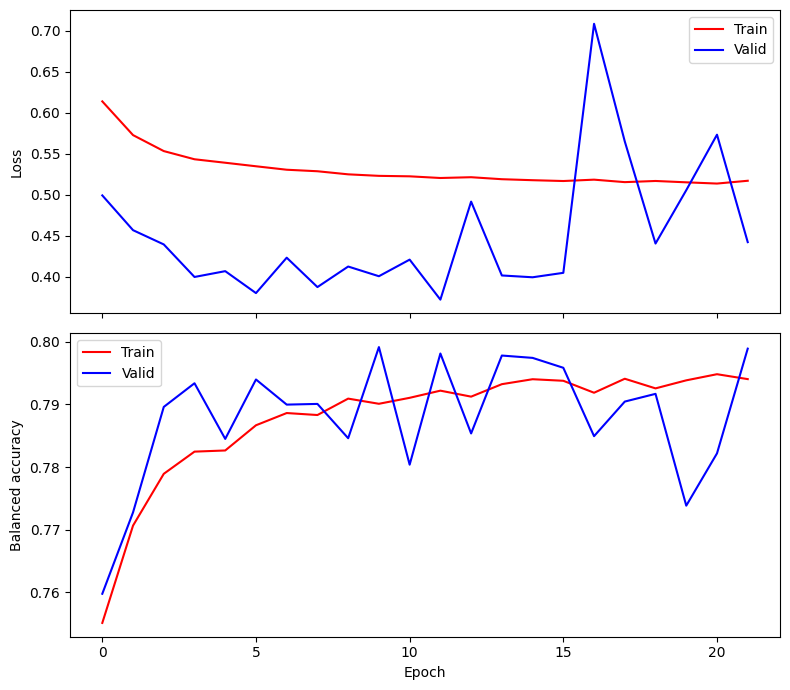

In [18]:
df = pd.DataFrame(clf.history.to_list())
df.index.name = 'Epoch'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
df[['train_loss', 'valid_loss']].plot(color=['r', 'b'], ax=ax1)
df[['train_bal_acc', 'valid_bal_acc']].plot(color=['r', 'b'], ax=ax2)
ax1.set_ylabel('Loss')
ax2.set_ylabel('Balanced accuracy')
ax1.legend(['Train', 'Valid'])
ax2.legend(['Train', 'Valid'])
fig.tight_layout()
plt.show()

## 9. Evaluation

We report the same metrics as in the RF notebook: accuracy, macro F1, Cohen's kappa, confusion matrices, per-class classification reports, and AUCPR curves.

In [24]:
# Keep evaluation on CPU during local debugging to avoid device mismatch.
if DEBUG_CPU and hasattr(clf, 'module_'):
    clf.module_.cpu()
    clf.device = 'cpu'
    print('Moved trained model to CPU for evaluation.')

y_pred_val = clf.predict(X_val)
y_pred_st = clf.predict(X_st)

val_metrics = evaluate.get_predictions(y_val, y_pred_val)
st_metrics = evaluate.get_predictions(y_st, y_pred_st)

acc_sc = val_metrics['accuracy']
f1_sc = val_metrics['macro_f1']
kappa_sc = val_metrics['kappa']

acc_st = st_metrics['accuracy']
f1_st = st_metrics['macro_f1']
kappa_st = st_metrics['kappa']

print('=' * 50)
print('   RESULTS SUMMARY')
print('=' * 50)
print(f'  Metric       SC -> SC    SC -> ST    Drop')
print('-' * 44)
print(f'  Accuracy     {acc_sc:.3f}       {acc_st:.3f}       {acc_sc - acc_st:+.3f}')
print(f'  Macro F1     {f1_sc:.3f}       {f1_st:.3f}       {f1_sc - f1_st:+.3f}')
print(f'  Kappa        {kappa_sc:.3f}       {kappa_st:.3f}       {kappa_sc - kappa_st:+.3f}')
print('=' * 50)


   RESULTS SUMMARY
  Metric       SC -> SC    SC -> ST    Drop
--------------------------------------------
  Accuracy     0.857       0.738       +0.119
  Macro F1     0.772       0.685       +0.087
  Kappa        0.775       0.643       +0.132


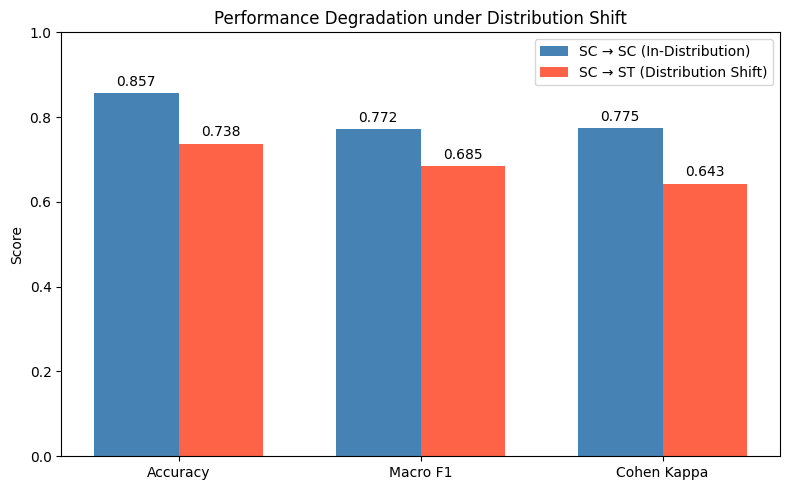

In [25]:
# Visualize performance drop across metrics
metrics = ['Accuracy', 'Macro F1', 'Cohen Kappa']
sc_scores = [acc_sc, f1_sc, kappa_sc]
st_scores = [acc_st, f1_st, kappa_st]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width / 2, sc_scores, width, label='SC → SC (In-Distribution)', color='steelblue')
bars2 = ax.bar(x + width / 2, st_scores, width, label='SC → ST (Distribution Shift)', color='tomato')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Performance Degradation under Distribution Shift')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

### 9.1 Confusion Matrix

We compare the confusion matrices for the held-out Sleep Cassette validation split and the Sleep Telemetry cohort.

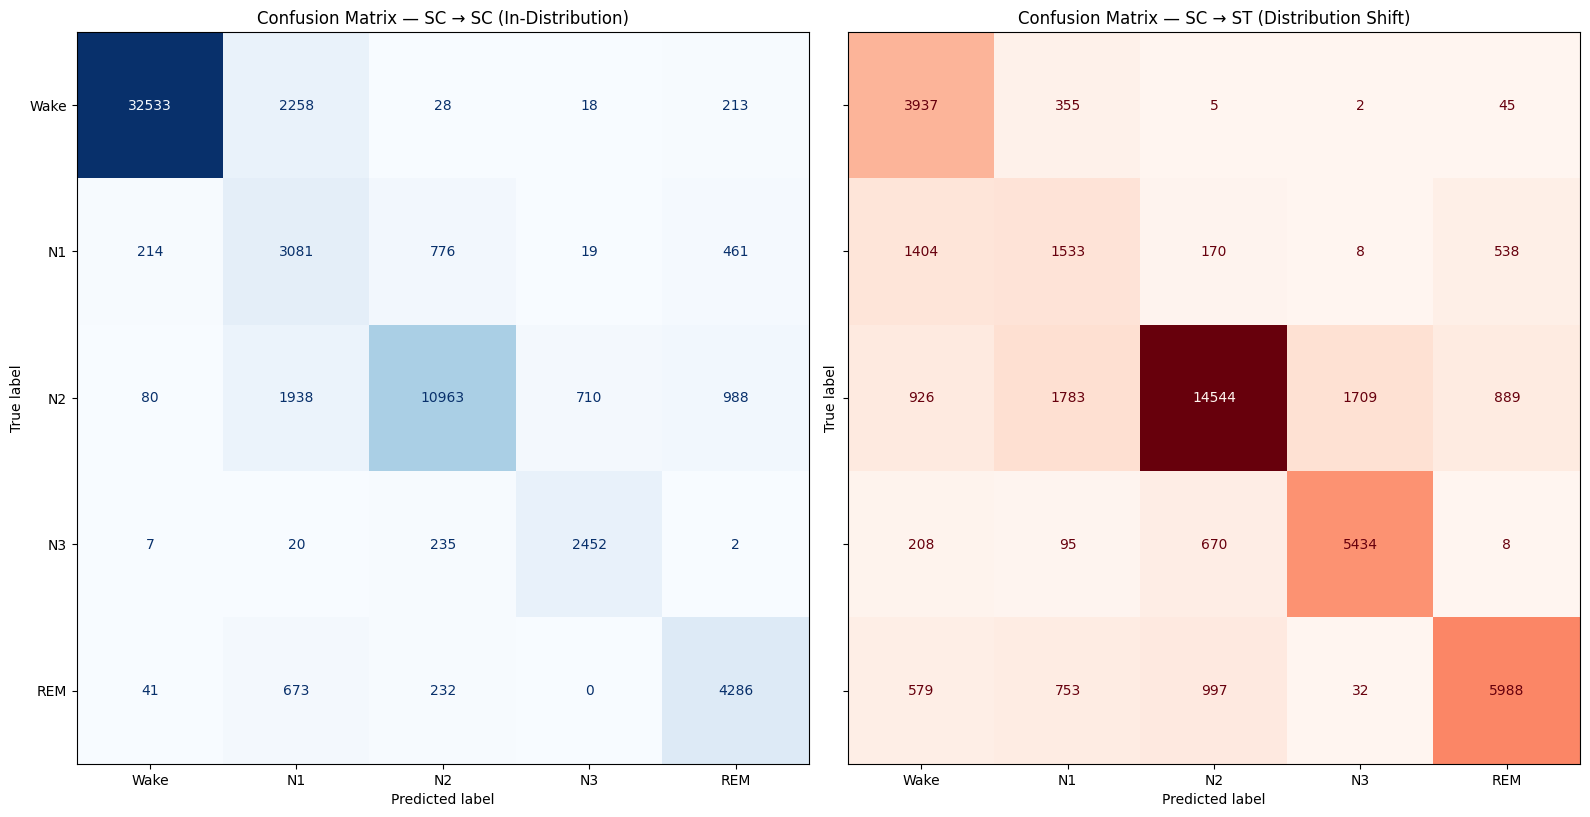

In [26]:
class_ids = [0, 1, 2, 3, 4]
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

cm_sc = confusion_matrix(y_val, y_pred_val, labels=class_ids)
cm_st = confusion_matrix(y_st, y_pred_st, labels=class_ids)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
ConfusionMatrixDisplay(confusion_matrix=cm_sc, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — SC → SC (In-Distribution)')

ConfusionMatrixDisplay(confusion_matrix=cm_st, display_labels=class_names).plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Confusion Matrix — SC → ST (Distribution Shift)')

plt.tight_layout()
plt.show() 

### 9.2 Per-Class Analysis

A class-wise report helps identify which stages degrade most under the cohort shift.

In [27]:
print('Per-class report — SC → SC (In-Distribution):')
print(classification_report(y_val, y_pred_val, labels=class_ids, target_names=class_names, zero_division=0))

print('Per-class report — SC → ST (Distribution Shift):')
print(classification_report(y_st, y_pred_st, labels=class_ids, target_names=class_names, zero_division=0))

Per-class report — SC → SC (In-Distribution):
              precision    recall  f1-score   support

        Wake       0.99      0.93      0.96     35050
          N1       0.39      0.68      0.49      4551
          N2       0.90      0.75      0.81     14679
          N3       0.77      0.90      0.83      2716
         REM       0.72      0.82      0.77      5232

    accuracy                           0.86     62228
   macro avg       0.75      0.81      0.77     62228
weighted avg       0.89      0.86      0.87     62228

Per-class report — SC → ST (Distribution Shift):
              precision    recall  f1-score   support

        Wake       0.56      0.91      0.69      4344
          N1       0.34      0.42      0.38      3653
          N2       0.89      0.73      0.80     19851
          N3       0.76      0.85      0.80      6415
         REM       0.80      0.72      0.76      8349

    accuracy                           0.74     42612
   macro avg       0.67      0.72   

### 9.3 AUCPR

We finish with one-vs-rest AUCPR curves for the five sleep stages, matching the RF notebook's summary style.

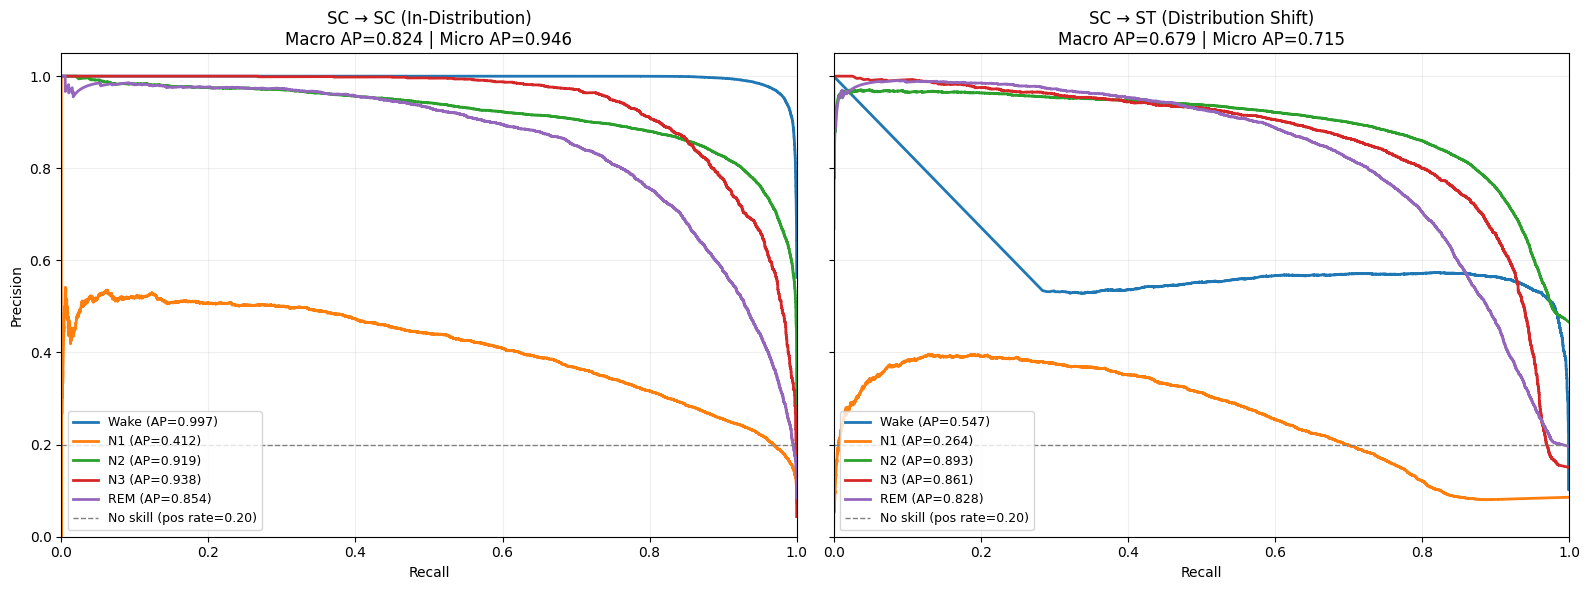

In [28]:
evaluate.plot_aucpr_multiclass(clf, X_val, y_val, X_st, y_st, class_ids, class_names)

---

## 10. Discussion

### Key ideas

- The CNN uses raw epoched EEG signals (only EEG channels are used) so it can learn discriminative time-domain representations instead of relying on handcrafted PSD summaries.
- The evaluation setup stays the same as the RF notebook: subject-level SC validation, SC → SC metrics, and SC → ST distribution-shift metrics.

### Limitations
- We only added 1 split test, for future work cross-fold validation.